## Бенчмаркинг и проверка гипотез

Входные данные: `data_processed/analysis_objects.csv`  
Выходные данные: таблицы, графики в `figures/`

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

ROOT = Path(".")

### Загрузка и подготовка выборки

In [119]:
obj_all = pd.read_csv(ROOT / "data_processed" / "analysis_objects_core.csv")
print(f"Всего объектов в финальной выборке: {len(obj_all)}")

Всего объектов в финальной выборке: 67


Смотрим на объекты с маленькой мощностью, чтобы решить, включать ли их в анализ

In [120]:
small = obj_all[obj_all["places"].notna() & (obj_all["places"] < 50)].sort_values("places")
print(f"Объектов с places < 50: {len(small)}")

Объектов с places < 50: 9


In [121]:
for _, row in small.iterrows():
    cost = row["cost_nom"] / 1e6 if "cost_nom" in row and row["cost_nom"] > 0 else None
    cost_str = f"{cost:.0f}M" if cost else "нет данных"
    print(f"  places={int(row['places'])} | {cost_str} | {str(row['publication_name'])}")

  places=13 | 1649M | ВЫПОЛНЕНИЕ РАБОТ ПО ОБЪЕКТУ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА: «СТРОИТЕЛЬСТВО ШКОЛЫ В М/Р РАБОЧИЙ ПОСЕЛОК Г. ПЕРМЬ»
  places=14 | 102M | Выполнение строительно-монтажных и прочих работ, в том числе установка и монтаж оборудования
  places=15 | 1351M | Выполнение работ по строительству объекта: "Строительство средней общеобразовательной школы в 6-м микрорайоне в г. Йошкар-Оле Республики Марий Эл" с использованием типовой проектной документации объекта "Строительство средней общеобразовательной ш...
  places=22 | 367M | Выполнение строительно-монтажных и прочих работ, в том числе установка и монтаж оборудования
  places=22 | 1652M | Выполнение строительно-монтажных и прочих работ, в том числе установка и монтаж оборудования
  places=25 | 1386M | Разработка проектной документации и выполнение инженерных изысканий, выполнение работ по строительству объекта: «Строительство нового корпуса МАОУ «Инженерная школа» г. Перми по ул. Академика Веденеева»
  places=25 | 486M | № зз-19

Можно сделать фильтр на 50–5000 мест — фильтр ошибок NLP-парсинга поля places:
* ниже 50 (в данных: 13–42): судя по стоимостям (400M–1600М), это полноценные школы, у которых парсер вытащил неверное число (номер этажа, число классов и тп) вместо мощности. unit_cost_base = cost / 13 даст бессмысленный результат.
* выше 5000 (21847, 45326 и тп): NLP извлек площадь в $м^2$ вместо мощности

Такие объекты исключаются из расчета удельной стоимости

In [122]:
df = obj_all[
    obj_all["places"].notna() &
    obj_all["places"].between(50, 5000) &
    obj_all["unit_cost_base"].notna()
].copy()


df["ucb_tys"] = df["unit_cost_base"] / 1000  # тыс. руб./место

region_names = {
    "Республика Башкортостан": "Башкортостан",
    "Республика Марий Эл": "Марий Эл",
    "Республика Мордовия": "Мордовия",
    "Республика Татарстан (Татарстан)": "Татарстан",
    "Удмуртская Республика": "Удмуртия",
    "Чувашская Республика - Чувашия":   "Чувашия",
    "Пермский край": "Пермский край",
    "Кировская область": "Кировская обл.",
    "Нижегородская область": "Нижегородская обл.",
    "Оренбургская область": "Оренбургская обл.",
    "Пензенская область": "Пензенская обл.",
    "Самарская область": "Самарская обл.",
    "Саратовская область": "Саратовская обл.",
    "Ульяновская область": "Ульяновская обл.",
}
df["region_short"] = df["region_std"].map(region_names).fillna(df["region_std"])

work_type_names = {
    "new_construction": "Новое строительство",
    "design_and_construction": "ПИР + строительство",
    "completion": "Завершение строительства",
    "annex": "Пристройка/корпус",
    "design_only": "Только проектирование",
}
df["work_type_ru"] = df["work_type"].map(work_type_names).fillna(df["work_type"])

print(f"Рабочая выборка: {len(df)} объектов")
print(f"Исключено (ошибки парсинга places): {len(obj_all) - len(df)}")

Рабочая выборка: 52 объектов
Исключено (ошибки парсинга places): 15


In [123]:
print(f"По регионам:")
print(df.groupby("region_short").size().sort_values(ascending=False).to_string())

По регионам:
region_short
Пермский край         8
Башкортостан          7
Нижегородская обл.    7
Мордовия              6
Оренбургская обл.     4
Удмуртия              4
Чувашия               4
Саратовская обл.      3
Кировская обл.        2
Марий Эл              2
Пензенская обл.       2
Татарстан             2
Ульяновская обл.      1


In [124]:
print(f"По типу работ:")
print(df.groupby("work_type_ru").size().sort_values(ascending=False).to_string())

По типу работ:
work_type_ru
Новое строительство    39
ПИР + строительство    13


### Описательная статистика удельной стоимости

In [125]:
desc = df["ucb_tys"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).round(0)
cv = df["ucb_tys"].std() / df["ucb_tys"].mean()
p90p10 = df["ucb_tys"].quantile(0.90) / df["ucb_tys"].quantile(0.10)
p75p25 = df["ucb_tys"].quantile(0.75) / df["ucb_tys"].quantile(0.25)

print("Удельная стоимость (тыс. руб./место, цены 2025Q4):")
print(desc.to_string())

Удельная стоимость (тыс. руб./место, цены 2025Q4):
count       52.0
mean      3334.0
std       8405.0
min         13.0
10%        603.0
25%       1079.0
50%       1589.0
75%       2689.0
90%       5356.0
max      61430.0


In [126]:
print(f"Коэффициент вариации: {cv:.2f}")
print(f"P90/P10: {p90p10:.1f}x")
print(f"P75/P25: {p75p25:.1f}x")

Коэффициент вариации: 2.52
P90/P10: 8.9x
P75/P25: 2.5x


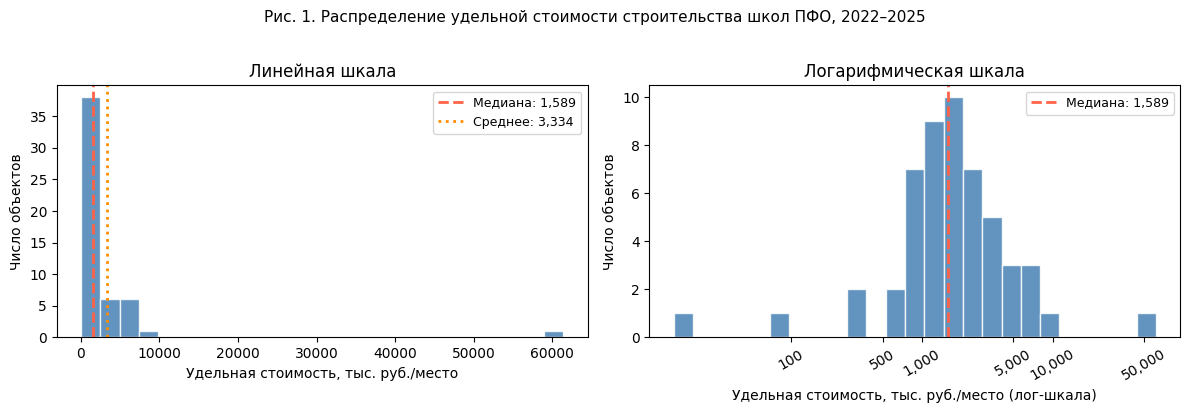

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df["ucb_tys"], bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(df["ucb_tys"].median(), color="tomato", lw=2, linestyle="--",
           label=f"Медиана: {df['ucb_tys'].median():,.0f}")
ax.axvline(df["ucb_tys"].mean(), color="darkorange", lw=2, linestyle=":",
           label=f"Среднее: {df['ucb_tys'].mean():,.0f}")
ax.set_xlabel("Удельная стоимость, тыс. руб./место")
ax.set_ylabel("Число объектов")
ax.set_title("Линейная шкала")
ax.legend(fontsize=9)

ax = axes[1]
log_vals = np.log10(df["ucb_tys"].clip(lower=1))
ax.hist(log_vals, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(np.log10(df["ucb_tys"].median()), color="tomato", lw=2, linestyle="--",
           label=f"Медиана: {df['ucb_tys'].median():,.0f}")
ticks = [100, 500, 1000, 5000, 10000, 50000]
ax.set_xticks([np.log10(t) for t in ticks])
ax.set_xticklabels([f"{t:,}" for t in ticks], rotation=30)
ax.set_xlabel("Удельная стоимость, тыс. руб./место (лог-шкала)")
ax.set_ylabel("Число объектов")
ax.set_title("Логарифмическая шкала")
ax.legend(fontsize=9)

fig.suptitle("Рис. 1. Распределение удельной стоимости строительства школ ПФО, 2022–2025",
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

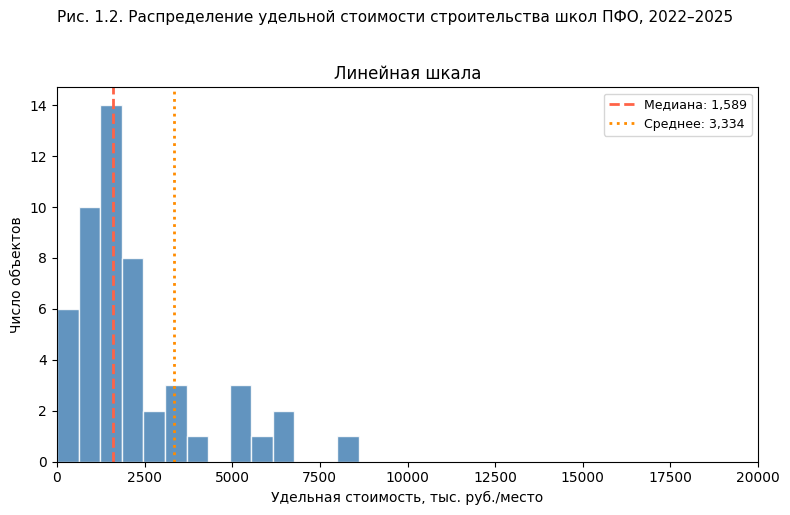

In [128]:
fig, ax = plt.subplots(figsize=(8, 5)) 

ax.hist(df["ucb_tys"], bins=100, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(df["ucb_tys"].median(), color="tomato", lw=2, linestyle="--",
           label=f"Медиана: {df['ucb_tys'].median():,.0f}")
ax.axvline(df["ucb_tys"].mean(), color="darkorange", lw=2, linestyle=":",
           label=f"Среднее: {df['ucb_tys'].mean():,.0f}")

ax.set_xlabel("Удельная стоимость, тыс. руб./место")
ax.set_ylabel("Число объектов")
ax.set_title("Линейная шкала")
ax.set_xlim(0, 20000)
ax.legend(fontsize=9)

fig.suptitle("Рис. 1.2. Распределение удельной стоимости строительства школ ПФО, 2022–2025",
             fontsize=11, y=1.02)

fig.tight_layout()
plt.show()

### Региональные различия удельной стоимости

Проверяю H1a: значимо ли различаются регионы по удельной стоимости, использую тест Краскела-Уоллиса, потому что данные не нормально распределены и групп много

In [129]:
reg_stats = df.groupby("region_short")["ucb_tys"].agg(
    n="count", медиана="median", среднее="mean", ст_откл="std"
).round(0)
reg_stats["Q25"] = df.groupby("region_short")["ucb_tys"].quantile(0.25).round(0)
reg_stats["Q75"] = df.groupby("region_short")["ucb_tys"].quantile(0.75).round(0)
reg_stats = reg_stats.sort_values("медиана", ascending=False)

print("Удельная стоимость по регионам (тыс. руб./место):")
print(reg_stats.to_string())

Удельная стоимость по регионам (тыс. руб./место):
                    n  медиана  среднее  ст_откл     Q25     Q75
region_short                                                    
Удмуртия            4   4014.0   3696.0   3053.0  1475.0  6235.0
Пермский край       8   3096.0  10314.0  20736.0  1543.0  5364.0
Пензенская обл.     2   2348.0   2348.0    377.0  2215.0  2482.0
Татарстан           2   2330.0   2330.0   2156.0  1568.0  3093.0
Башкортостан        7   2324.0   2860.0   1866.0  1357.0  4359.0
Чувашия             4   1894.0   1867.0    489.0  1512.0  2249.0
Ульяновская обл.    1   1585.0   1585.0      NaN  1585.0  1585.0
Марий Эл            2   1568.0   1568.0   1128.0  1169.0  1967.0
Оренбургская обл.   4   1514.0   1548.0    248.0  1421.0  1641.0
Кировская обл.      2   1351.0   1351.0    441.0  1195.0  1507.0
Нижегородская обл.  7   1350.0   1107.0    668.0   719.0  1488.0
Саратовская обл.    3   1092.0   3379.0   4041.0  1046.0  4569.0
Мордовия            6    945.0   1290.0 

Тест Краскела-Уоллиса — проверяем, есть ли значимые различия между регионами:

In [130]:
groups_reg = [grp["ucb_tys"].values for _, grp in df.groupby("region_short") if len(grp) >= 2]
kw_stat, kw_pval = stats.kruskal(*groups_reg)
print(f"H={kw_stat:.2f}, p={kw_pval:.4f}")

H=10.48, p=0.4877


Вывод: различия не достигают уровня значимости $\alpha$=0.05

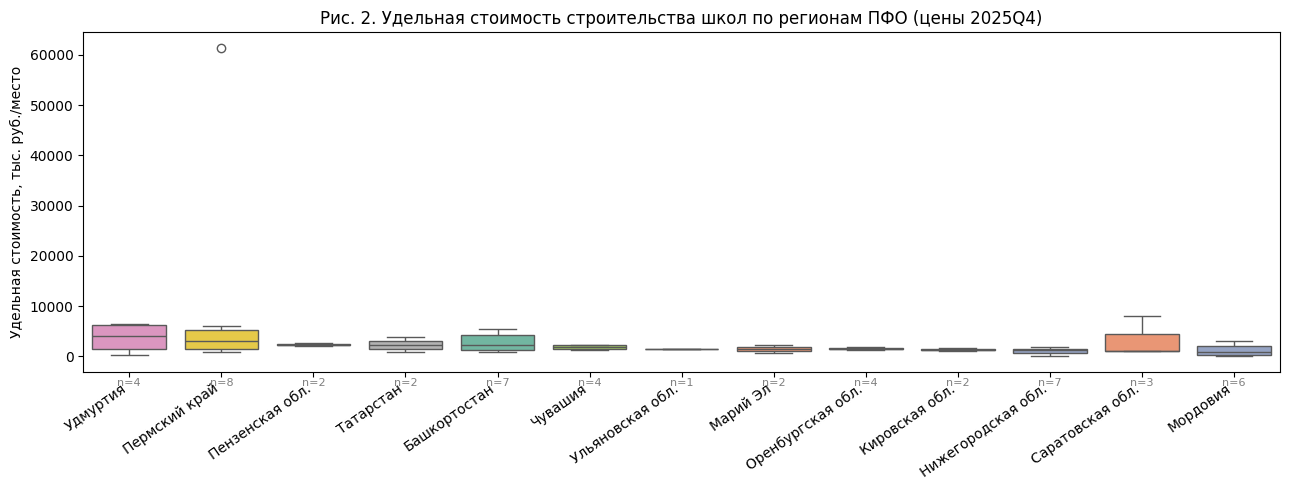

In [131]:
reg_order = reg_stats.index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="region_short", y="ucb_tys", order=reg_order,
            hue="region_short", legend=False, palette="Set2", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Рис. 2. Удельная стоимость строительства школ по регионам ПФО (цены 2025Q4)")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")

ymin, ymax = ax.get_ylim()
for i, reg in enumerate(reg_order):
    n = int(reg_stats.loc[reg, "n"])
    ax.text(i, ymin - ymax * 0.02, f"n={n}", ha="center", va="top", fontsize=8, color="gray")

fig.tight_layout()
plt.show()

Без выбросов:

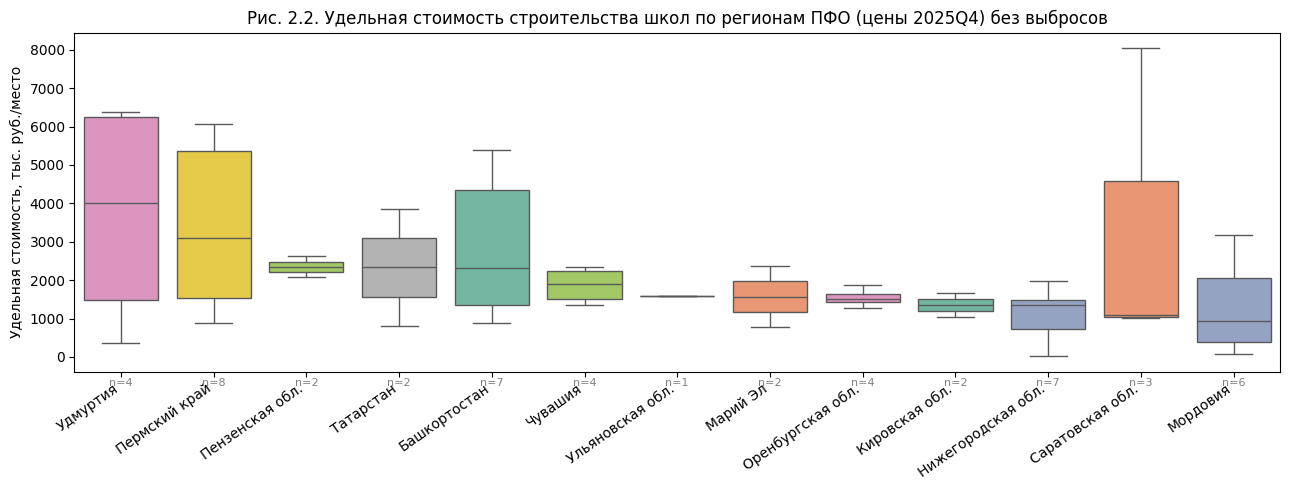

In [132]:
reg_order = reg_stats.index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="region_short", y="ucb_tys", order=reg_order,
            hue="region_short", legend=False, palette="Set2", ax=ax, showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Рис. 2.2. Удельная стоимость строительства школ по регионам ПФО (цены 2025Q4) без выбросов")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")

ymin, ymax = ax.get_ylim()
for i, reg in enumerate(reg_order):
    n = int(reg_stats.loc[reg, "n"])
    ax.text(i, ymin - ymax * 0.02, f"n={n}", ha="center", va="top", fontsize=8, color="gray")

fig.tight_layout()
plt.show()

### Различия по типу работ

H1b: различается ли стоимость в зависимости от того, включает ли контракт проектирование (ПИР+строительство) или только строительство, для двух групп использую тест Манна-Уитни

In [133]:
type_stats = (
    df.groupby("work_type_ru")["ucb_tys"]
    .agg(["count", "median", "mean", "std"])
    .round(0)
)

type_stats.columns = ["n", "медиана", "среднее", "ст.откл."]
type_stats = type_stats.sort_values("медиана", ascending=False)

print("Удельная стоимость по типу работ (тыс. руб./место):")
print(type_stats.to_string())

Удельная стоимость по типу работ (тыс. руб./место):
                      n  медиана  среднее  ст.откл.
work_type_ru                                       
ПИР + строительство  13   1663.0   6721.0   16525.0
Новое строительство  39   1585.0   2206.0    1830.0


Манн-Уитни: новое строительство vs ПИР+строительство

In [134]:
nc_vals = df[df["work_type"] == "new_construction"]["ucb_tys"]
dc_vals = df[df["work_type"] == "design_and_construction"]["ucb_tys"]

In [135]:
mw_stat, mw_pval = None, None
mw_stat, mw_pval = stats.mannwhitneyu(nc_vals, dc_vals, alternative="two-sided")
print(f"U={mw_stat:.0f}, p={mw_pval:.4f}")
print(f"Медианы: новое={nc_vals.median():,.0f}, ПИР+стр={dc_vals.median():,.0f} тыс. руб./место")
print(f"p-value: {mw_pval}")

U=238, p=0.7513
Медианы: новое=1,585, ПИР+стр=1,663 тыс. руб./место
p-value: 0.7512542884053082


Вывод: различие не значимо

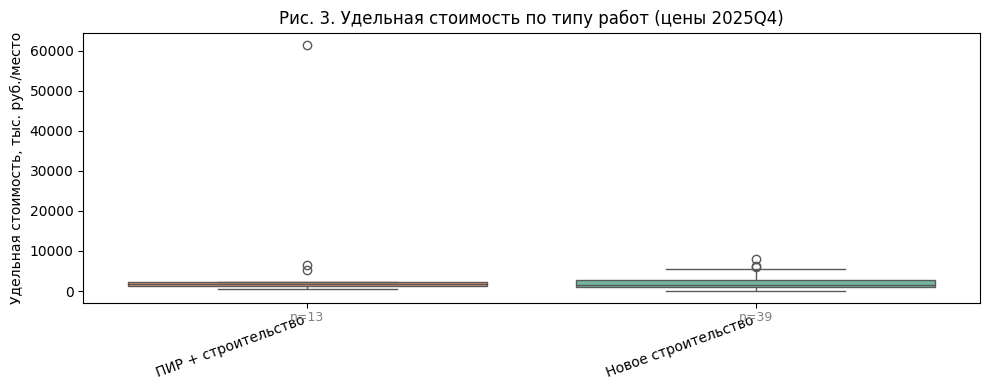

In [136]:
wt_order = type_stats.index.tolist()
df_wt = df[df["work_type_ru"].isin(wt_order)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_wt, x="work_type_ru", y="ucb_tys", order=wt_order,
            hue="work_type_ru", legend=False, palette="Set2", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Рис. 3. Удельная стоимость по типу работ (цены 2025Q4)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

ymin, ymax = ax.get_ylim()
for i, wt in enumerate(wt_order):
    n = int(type_stats.loc[wt, "n"])
    ax.text(i, ymin - ymax * 0.03, f"n={n}", ha="center", va="top", fontsize=9, color="gray")

fig.tight_layout()
plt.show()

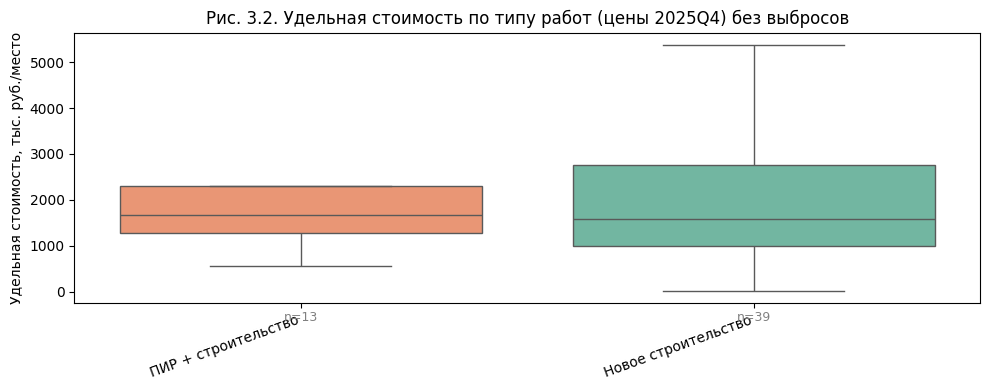

In [137]:
wt_order = type_stats.index.tolist()
df_wt = df[df["work_type_ru"].isin(wt_order)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_wt, x="work_type_ru", y="ucb_tys", order=wt_order,
            hue="work_type_ru", legend=False, palette="Set2", ax=ax, showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Рис. 3.2. Удельная стоимость по типу работ (цены 2025Q4) без выбросов")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

ymin, ymax = ax.get_ylim()
for i, wt in enumerate(wt_order):
    n = int(type_stats.loc[wt, "n"])
    ax.text(i, ymin - ymax * 0.03, f"n={n}", ha="center", va="top", fontsize=9, color="gray")

fig.tight_layout()
plt.show()

### Конкуренция и удельная стоимость

H2: есть ли связь между уровнем конкуренции (снижение от НМЦК) и удельной стоимостью. Корреляция Спирмена подходит, потому что данные ненормальны и есть много нулей (несостоявшиеся торги)

In [138]:
df_comp = df[df["discount_pct_mean"].notna() & (df["discount_pct_mean"] >= 0)].copy()
print(f"Объектов с данными о конкуренции: {len(df_comp)}")
print(f"Медианная скидка: {df_comp['discount_pct_mean'].median()*100:.3f}%")
print(f"Скидка = 0 (нет торгов): {(df_comp['discount_pct_mean'] == 0).sum()} объектов")

Объектов с данными о конкуренции: 24
Медианная скидка: 0.002%
Скидка = 0 (нет торгов): 11 объектов


In [139]:
rho_comp, pval_comp = stats.spearmanr(df_comp["discount_pct_mean"], df_comp["ucb_tys"])
print(f"Корреляция Спирмена (скидка, уд.стоимость): ρ={rho_comp:.3f}, p={pval_comp:.4f}")

if rho_comp < 0:
    print("Направление: отрицательная (больше скидка - ниже стоимость)")
else:
    print("Направление: положительная (больше скидка - выше стоимость)")

if pval_comp < 0.05:
    print("Статистически значимая (α=0.05)")
else:
    print("Статистически незначимая (α=0.05)")

Корреляция Спирмена (скидка, уд.стоимость): ρ=-0.003, p=0.9899
Направление: отрицательная (больше скидка - ниже стоимость)
Статистически незначимая (α=0.05)


Делим на 3 группы по уровню конкуренции

In [162]:
median_nonzero = df_comp.loc[df_comp["discount_pct_mean"] > 0, "discount_pct_mean"].median()

def competition_group(d):
    if d == 0:
        return "Нет торгов (скидка = 0)"
    elif d <= median_nonzero:
        return "Низкая (скидка ≤ медианы)"
    else:
        return "Высокая (скидка > медианы)"

df_comp["competition"] = df_comp["discount_pct_mean"].apply(competition_group)
comp_order = ["Нет торгов (скидка = 0)", "Низкая (скидка ≤ медианы)", "Высокая (скидка > медианы)"]

comp_tab = (
    df_comp.groupby("competition", observed=True)["ucb_tys"]
    .agg(["count", "median", "mean"]).round(0)
    .reindex(comp_order)
)

comp_tab.columns = ["n", "медиана", "среднее"]
print(f"Медианная скидка среди конкурентных торгов: {median_nonzero*100:.2f}%")

Медианная скидка среди конкурентных торгов: 0.50%


In [163]:
print("Удельная стоимость по уровню конкуренции:")
print(comp_tab.to_string())

Удельная стоимость по уровню конкуренции:
                             n  медиана  среднее
competition                                     
Нет торгов (скидка = 0)     11   1663.0   2417.0
Низкая (скидка ≤ медианы)    7   1879.0   2548.0
Высокая (скидка > медианы)   6   1732.0   2457.0


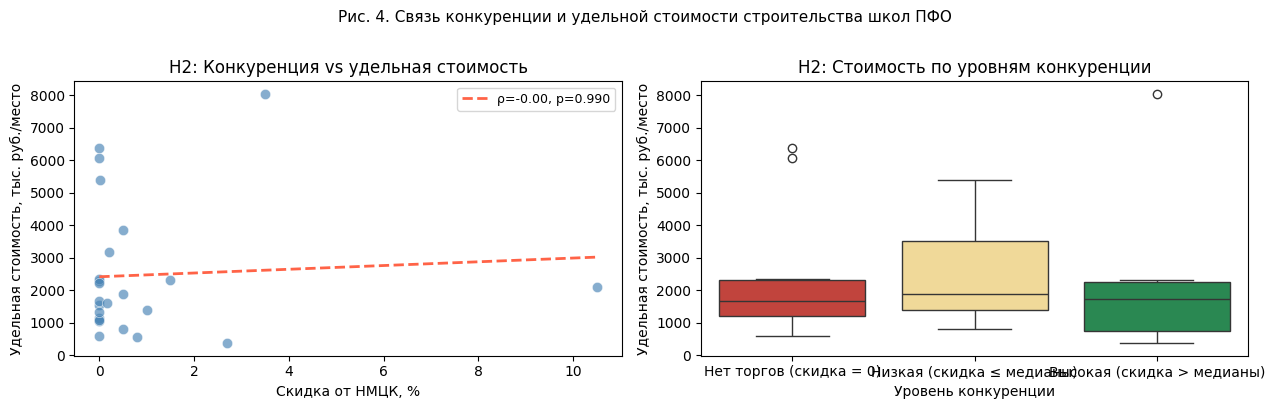

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(
    df_comp["discount_pct_mean"] * 100, df_comp["ucb_tys"],
    alpha=0.65, s=55, color="steelblue", edgecolors="white", linewidths=0.5
)
x_vals = df_comp["discount_pct_mean"] * 100
m, b = np.polyfit(x_vals, df_comp["ucb_tys"], 1)
xs = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(xs, m * xs + b, color="tomato", lw=2, linestyle="--",
        label=f"ρ={rho_comp:.2f}, p={pval_comp:.3f}")
ax.set_xlabel("Скидка от НМЦК, %")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("H2: Конкуренция vs удельная стоимость")
ax.legend(fontsize=9)

ax = axes[1]
sns.boxplot(
    data=df_comp, x="competition", y="ucb_tys",
    order=comp_order, hue="competition", legend=False,
    palette=["#d73027", "#fee08b", "#1a9850"], ax=ax
)
ax.set_xlabel("Уровень конкуренции")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("H2: Стоимость по уровням конкуренции")

fig.suptitle("Рис. 4. Связь конкуренции и удельной стоимости строительства школ ПФО",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

### Временная динамика удельной стоимости

In [ ]:
yr_stats = (
    df.groupby("year")["ucb_tys"]
    .agg(["count", "median", "mean",
          lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    .round(0)
)

yr_stats.columns = ["n", "медиана", "среднее", "Q25", "Q75"]
print("Удельная стоимость по годам (тыс. руб./место, цены 2025Q4):")
print(yr_stats.to_string())

Удельная стоимость по годам (тыс. руб./место, цены 2025Q4):
       n  медиана  среднее     Q25     Q75
year                                      
2022  18   1366.0   2326.0  1190.0  2755.0
2023   9   1465.0   1690.0  1039.0  1845.0
2024  10   1589.0   1971.0  1035.0  2311.0
2025  15   2324.0   6440.0  1616.0  3368.0


In [148]:
rho_time, pval_time = stats.spearmanr(df["year"], df["ucb_tys"])
print(f"Корреляция Спирмена (год, уд.стоимость): ρ={rho_time:.3f}, p={pval_time:.4f}")

time_sig = "значимый тренд" if pval_time < 0.05 else "значимый тренд отсутствует"
print(f"Вывод: {time_sig} (α=0.05)")

Корреляция Спирмена (год, уд.стоимость): ρ=0.169, p=0.2322
Вывод: значимый тренд отсутствует (α=0.05)


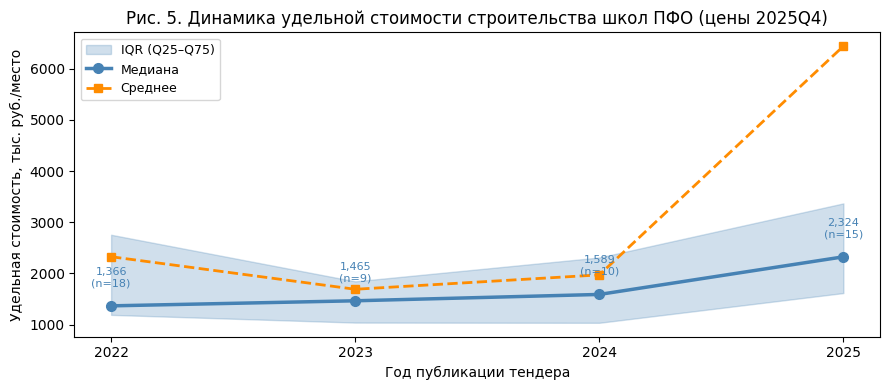

In [149]:
fig, ax = plt.subplots(figsize=(9, 4))

years = yr_stats.index.tolist()
medians = yr_stats["медиана"].tolist()
q25_yr = yr_stats["Q25"].tolist()
q75_yr = yr_stats["Q75"].tolist()
means = yr_stats["среднее"].tolist()
ns = yr_stats["n"].tolist()

ax.fill_between(years, q25_yr, q75_yr, alpha=0.25, color="steelblue", label="IQR (Q25–Q75)")
ax.plot(years, medians, marker="o", color="steelblue", lw=2.5, markersize=7, label="Медиана")
ax.plot(years, means, marker="s", color="darkorange",
        lw=2, markersize=6, linestyle="--", label="Среднее")

for yr, med, n in zip(years, medians, ns):
    ax.annotate(f"{med:,.0f}\n(n={int(n)})", xy=(yr, med),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=8, color="steelblue")

ax.set_xlabel("Год публикации тендера")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Рис. 5. Динамика удельной стоимости строительства школ ПФО (цены 2025Q4)")
ax.set_xticks(years)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

### Эффект масштаба: мощность -> удельная стоимость

In [ ]:
rho_scale, pval_scale = stats.spearmanr(df["places"], df["ucb_tys"])
print(f"Корреляция Спирмена (мощность, уд.стоимость): ρ={rho_scale:.3f}, p={pval_scale:.4f}")

scale_sig = "значимый эффект масштаба" if pval_scale < 0.05 else "не значимо"
scale_dir = "отрицательная" if rho_scale < 0 else "положительная"
print(f"Вывод: {scale_dir} зависимость, {scale_sig} (α=0.05)")

Корреляция Спирмена (мощность, уд.стоимость): ρ=-0.635, p=0.0000
Вывод: отрицательная зависимость, значимый эффект масштаба (α=0.05)


In [ ]:
df["size_group"] = pd.cut(
    df["places"],
    bins=[0, 300, 600, 1000, 2000, 5000],
    labels=["≤300 мест", "301–600", "601–1000", "1001–2000", ">2000"]
)

size_tab = df.groupby("size_group", observed=True)["ucb_tys"].agg(["count","median","mean"]).round(0)
size_tab.columns = ["n", "медиана", "среднее"]
print("\nУдельная стоимость по мощности объекта:")
print(size_tab.to_string())


Удельная стоимость по мощности объекта:
             n  медиана  среднее
size_group                      
≤300 мест   17   3855.0   7319.0
301–600     17   1350.0   1542.0
601–1000     6   1575.0   1559.0
1001–2000   10   1222.0   1203.0
>2000        2    676.0    676.0


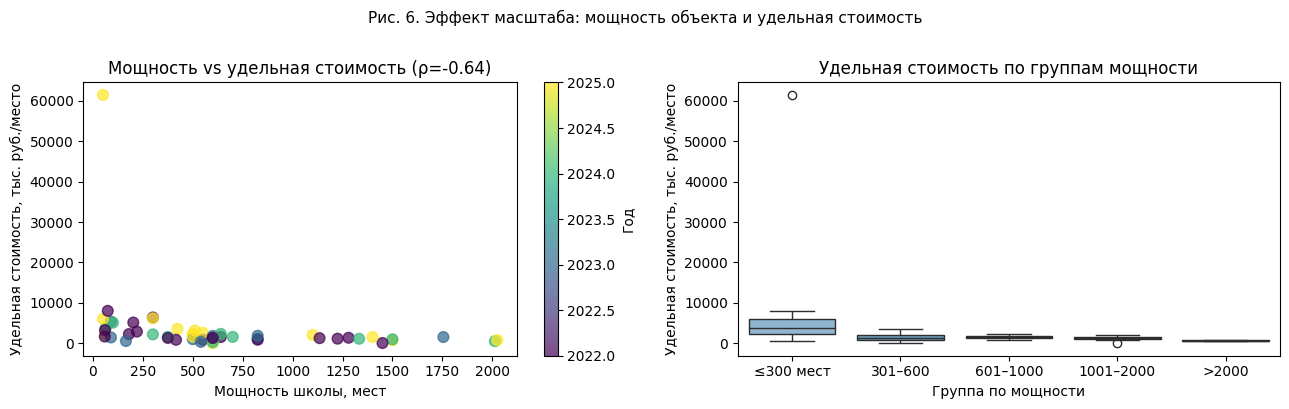

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
sc = ax.scatter(df["places"], df["ucb_tys"], c=df["year"],
                cmap="viridis", alpha=0.7, s=60)
plt.colorbar(sc, ax=ax, label="Год")
ax.set_xlabel("Мощность школы, мест")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title(f"Мощность vs удельная стоимость (ρ={rho_scale:.2f})")

ax = axes[1]
sns.boxplot(
    data=df[df["size_group"].notna()],
    x="size_group", y="ucb_tys",
    order=["≤300 мест", "301–600", "601–1000", "1001–2000", ">2000"],
    hue="size_group", legend=False, palette="Blues_d",
    ax=ax
)
ax.set_xlabel("Группа по мощности")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость по группам мощности")

fig.suptitle("Рис. 6. Эффект масштаба: мощность объекта и удельная стоимость",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

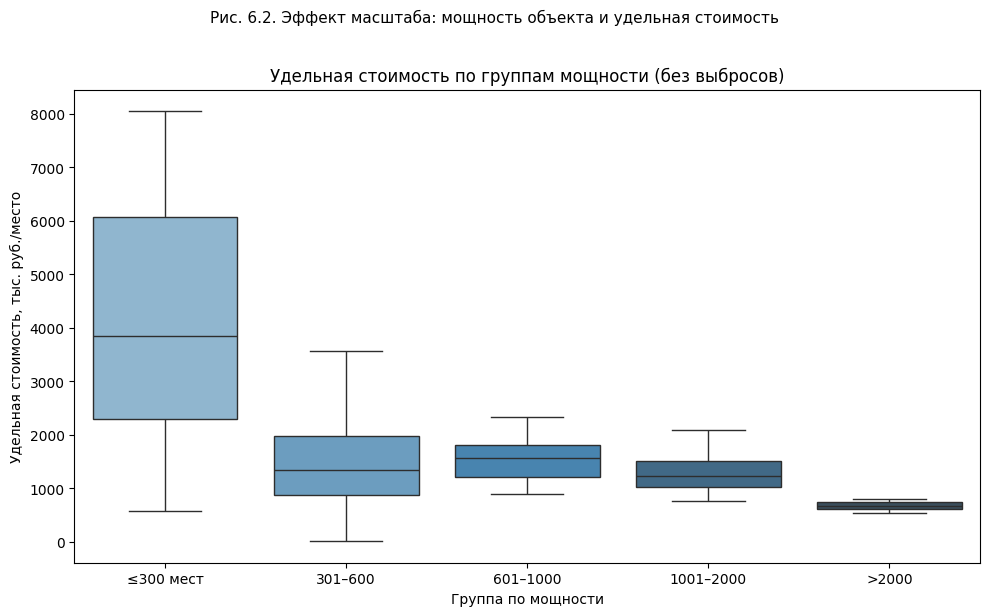

In [167]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df[df["size_group"].notna()],
    x="size_group", 
    y="ucb_tys",
    order=["≤300 мест", "301–600", "601–1000", "1001–2000", ">2000"],
    hue="size_group", 
    legend=False, 
    palette="Blues_d",
    ax=ax,
    showfliers=False
)

ax.set_xlabel("Группа по мощности")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость по группам мощности (без выбросов)")

fig.suptitle("Рис. 6.2. Эффект масштаба: мощность объекта и удельная стоимость",
             fontsize=11, y=1.02)

fig.tight_layout()
plt.show()

### Регрессионный анализ: объяснение вариации удельной стоимости

Чтобы проверить H1 («после учета характеристик проекта разброс стоимости снижается»), строю 3 OLS-регрессии на логарифмированных переменных, зависимая переменная — `ln(ucb_tys)` (логарифм удельной стоимости)

Логарифмирование обеих переменных позволяет интерпретировать коэффициент при `ln(places)` как эластичность: на сколько процентов меняется удельная стоимость при увеличении мощности на 1%

- M1: только масштаб — `ln_ucb ~ ln_places`
- M2: масштаб + год — добавляю год как контроль временного тренда
- M3: масштаб + год + тип работ — добавляю флаг «новое строительство»

In [ ]:
import statsmodels.formula.api as smf

df["ln_ucb"] = np.log(df["ucb_tys"])
df["ln_places"] = np.log(df["places"])
df["work_nc"] = (df["work_type"] == "new_construction").astype(int)

m1 = smf.ols("ln_ucb ~ ln_places", data=df).fit()
m2 = smf.ols("ln_ucb ~ ln_places + year", data=df).fit()
m3 = smf.ols("ln_ucb ~ ln_places + year + work_nc", data=df).fit()

print(f"{'':22s} {'M1':>10s} {'M2':>10s} {'M3':>10s}")
print("-" * 54)

all_vars = ["Intercept", "ln_places", "year", "work_nc"]
var_labels = {
    "Intercept": "Константа",
    "ln_places": "ln(места)",
    "year": "Год",
    "work_nc": "Новое стр-во (1=да)",
}

for v in all_vars:
    row = f"{var_labels[v]:22s}"
    
    for m in [m1, m2, m3]:
        if v in m.params:
            b, p = m.params[v], m.pvalues[v]
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else " "
            row += f"  {b:+.3f}{sig:3s}"
        else:
            row += f"  {'—':>8s}"

    print(row)

                               M1         M2         M3
------------------------------------------------------
Константа               +10.906***  -186.490     -229.046   
ln(места)               -0.584***  -0.590***  -0.618***
Год                            —  +0.098     +0.119   
Новое стр-во (1=да)            —         —  -0.634   


In [ ]:
for label, key in [("n", None), ("R²", "rsquared"), ("adj. R²", "rsquared_adj")]:
    row = f"{label:22s}"
    
    for m in [m1, m2, m3]:
        if key is None:
            row += f"  {int(m.nobs):>9d}"
        else:
            row += f"  {getattr(m, key):>9.3f}"
    print(row)

n                              52         52         52
R²                          0.279      0.289      0.343
adj. R²                     0.264      0.260      0.302


In [168]:
raw_cv = df["ucb_tys"].std() / df["ucb_tys"].mean()
print(f"Исходный CV удельной стоимости (уровень): {raw_cv:.2f}")
print(f"Остаточный std(ln) M1 (только масштаб): {m1.resid.std():.3f}")
print(f"Остаточный std(ln) M3 (все контроли): {m3.resid.std():.3f}")
print(f"M3 объясняет {m3.rsquared:.1%} дисперсии ln(ucb)")

Исходный CV удельной стоимости (уровень): 2.52
Остаточный std(ln) M1 (только масштаб): 1.006
Остаточный std(ln) M3 (все контроли): 0.961
M3 объясняет 34.3% дисперсии ln(ucb)


Проверяю, нет ли явных паттернов:

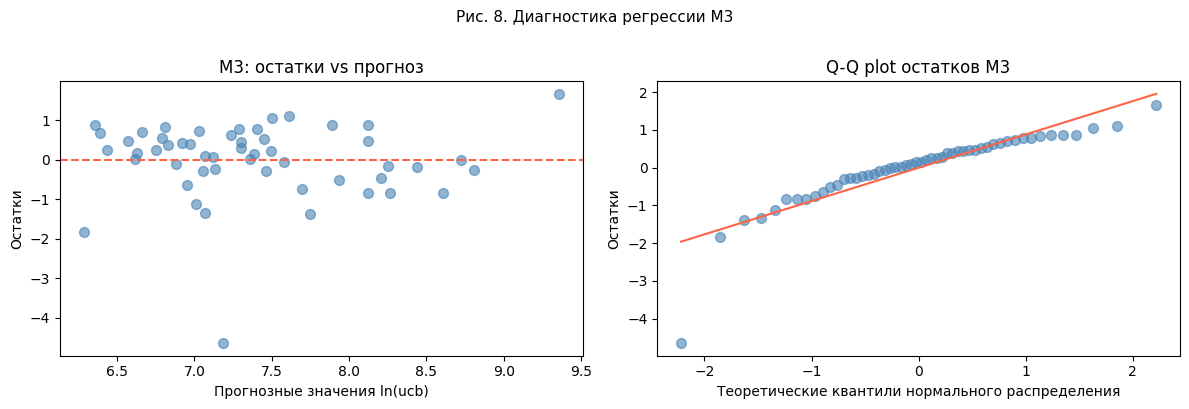

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(m3.fittedvalues, m3.resid, alpha=0.6, color="steelblue", s=50)
ax.axhline(0, color="tomato", lw=1.5, linestyle="--")
ax.set_xlabel("Прогнозные значения ln(ucb)")
ax.set_ylabel("Остатки")
ax.set_title("M3: остатки vs прогноз")

ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(m3.resid, dist="norm")
ax.scatter(osm, osr, alpha=0.6, color="steelblue", s=50)
ax.plot(osm, slope * np.array(osm) + intercept, color="tomato", lw=1.5)
ax.set_xlabel("Теоретические квантили нормального распределения")
ax.set_ylabel("Остатки")
ax.set_title("Q-Q plot остатков M3")

fig.suptitle("Рис. 8. Диагностика регрессии M3", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

### Выявление аномалий (Reference Class Forecasting / IQR-метод)

Выявляю аномалии методом IQR-fence на референсном классе (новое строительство + ПИР+строительство, 100–2000 мест, без пакетных закупок). Граница: выше P75 + 1.5·IQR — высокая стоимость, ниже P25 − 1.5·IQR — низкая.

In [170]:
ref_class = df[
    df["work_type"].isin(["new_construction", "design_and_construction"]) &
    ~df["any_package"] &
    df["places"].between(100, 2000)
].copy()
print(f"Референсный класс: {len(ref_class)} объектов")

Референсный класс: 41 объектов


In [172]:
rcf_p10 = ref_class["ucb_tys"].quantile(0.10)
rcf_p25 = ref_class["ucb_tys"].quantile(0.25)
rcf_med = ref_class["ucb_tys"].quantile(0.50)
rcf_p75 = ref_class["ucb_tys"].quantile(0.75)
rcf_p90 = ref_class["ucb_tys"].quantile(0.90)
rcf_iqr = rcf_p75 - rcf_p25
rcf_fence_high = rcf_p75 + 1.5 * rcf_iqr
rcf_fence_low  = max(rcf_p25 - 1.5 * rcf_iqr, 100)

print(f"Параметры референсного класса (тыс. руб./место):")
print(f"  P10={rcf_p10:,.0f}  P25={rcf_p25:,.0f}  P50={rcf_med:,.0f}  P75={rcf_p75:,.0f}  P90={rcf_p90:,.0f}")
print(f"  IQR={rcf_iqr:,.0f}")
print(f"  Граница высокой стоимости: > {rcf_fence_high:,.0f} тыс. руб./место")
print(f"  Граница низкой стоимости: < {rcf_fence_low:,.0f} тыс. руб./место")

Параметры референсного класса (тыс. руб./место):
  P10=585  P25=1,039  P50=1,562  P75=2,292  P90=3,568
  IQR=1,253
  Граница высокой стоимости: > 4,170 тыс. руб./место
  Граница низкой стоимости: < 100 тыс. руб./место


In [174]:
df["anomaly_high"] = df["ucb_tys"] > rcf_fence_high
df["anomaly_low"] = df["ucb_tys"] < rcf_fence_low
df["anomaly"] = df["anomaly_high"] | df["anomaly_low"]

print(f"\nАномалии во всём датасете ({len(df)} объектов):")
print(f"  Высокая стоимость: {df['anomaly_high'].sum()} объектов")
print(f"  Низкая стоимость: {df['anomaly_low'].sum()} объектов")
print(f"  Итого аномальных: {df['anomaly'].sum()} ({df['anomaly'].mean():.1%})")


Аномалии во всём датасете (52 объектов):
  Высокая стоимость: 8 объектов
  Низкая стоимость: 2 объектов
  Итого аномальных: 10 (19.2%)


In [178]:
anomalies = df[df["anomaly"]].copy()
anomalies["Тип аномалии"] = "низкая" 
anomalies.loc[anomalies["anomaly_high"], "Тип аномалии"] = "высокая"

anomalies["Скидка %"] = (anomalies["discount_pct_mean"] * 100).round(1)
rename_map = {
    "region_short": "Регион",
    "publication_name": "Название",
    "places": "Мест",
    "year": "Год",
    "ucb_tys": "Уд.стоимость"
}
anomalies = anomalies.rename(columns=rename_map)

cols = ["Регион", "Название", "Мест", "Год", "Уд.стоимость", "Скидка %", "Тип аномалии"]
anomalies = anomalies.sort_values("Уд.стоимость", ascending=False)

print(anomalies[cols].to_string(index=False, float_format="%.0f"))

            Регион                                                                                                                                                                                                                                                     Название  Мест  Год  Уд.стоимость  Скидка % Тип аномалии
     Пермский край                                                                                                                                                            ВЫПОЛНЕНИЕ РАБОТ ПО ОБЪЕКТУ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА: «СТРОИТЕЛЬСТВО ШКОЛЫ В М/Р ДКЖ, Г. ПЕРМЬ»    50 2025         61430       NaN      высокая
  Саратовская обл.                                                                                                           Выполнение работ по строительству объекта капитального строительства в сфере образования: "Школа в ЖК "Ласточкино" в Ленинском районе г. Саратова"    74 2022          8045         4      высокая
          Удмуртия                    зз

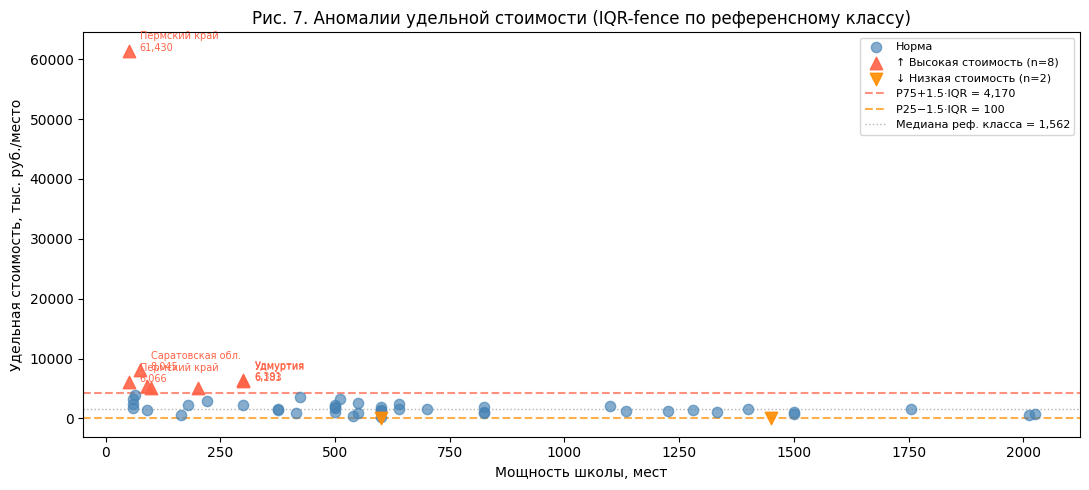

In [180]:
fig, ax = plt.subplots(figsize=(11, 5))

normal = df[~df["anomaly"]]
high = df[df["anomaly_high"]]
low = df[df["anomaly_low"]]

ax.scatter(normal["places"], normal["ucb_tys"],
           color="steelblue", alpha=0.65, s=55, label="Норма", zorder=3)
ax.scatter(high["places"], high["ucb_tys"],
           color="tomato", alpha=0.9, s=80, marker="^",
           label=f"↑ Высокая стоимость (n={len(high)})", zorder=4)
ax.scatter(low["places"], low["ucb_tys"],
           color="darkorange", alpha=0.9, s=80, marker="v",
           label=f"↓ Низкая стоимость (n={len(low)})", zorder=4)

ax.axhline(rcf_fence_high, color="tomato", lw=1.5, linestyle="--", alpha=0.7,
           label=f"P75+1.5·IQR = {rcf_fence_high:,.0f}")
ax.axhline(rcf_fence_low, color="darkorange", lw=1.5, linestyle="--", alpha=0.7,
           label=f"P25−1.5·IQR = {rcf_fence_low:,.0f}")
ax.axhline(rcf_med, color="gray", lw=1, linestyle=":", alpha=0.6,
           label=f"Медиана реф. класса = {rcf_med:,.0f}")

strict_high = rcf_p75 + 3.0 * rcf_iqr
for _, row in df[df["ucb_tys"] > strict_high].iterrows():
    ax.annotate(
        f"{row['region_short']}\n{row['ucb_tys']:,.0f}",
        xy=(row["places"], row["ucb_tys"]),
        xytext=(8, 0), textcoords="offset points",
        fontsize=7, color="tomato"
    )

ax.set_xlabel("Мощность школы, мест")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Рис. 7. Аномалии удельной стоимости (IQR-fence по референсному классу)")
ax.legend(fontsize=8, loc="upper right")

fig.tight_layout()
plt.show()

### Доверительные интервалы для корреляций (бутстрап)

При маленьком числе наблюдений одна p-value мало что говорит - для корреляций Спирмена считаю бутстрап: много раз случайно выбираю строки с возвращением и каждый раз заново считаю $\rho$. По получившимся значениям беру 2.5\% и 97.5\% — это примерный 95\%-ный интервал для \(\rho\)

In [181]:
rng = np.random.default_rng(42)
N_BOOT = 2000


def boot_spearman(x, y, n_boot=N_BOOT):
    """Бутстрап-интервал для rho Спирмена (строки с возвращением)."""
    xy = pd.DataFrame({"x": x, "y": y}).dropna()
    n = len(xy)
    if n < 5:
        return None, None, n
    xs = xy["x"].to_numpy()
    ys = xy["y"].to_numpy()
    rhos = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        r, _ = stats.spearmanr(xs[idx], ys[idx])
        if np.isfinite(r):
            rhos.append(r)
    rhos = np.array(rhos)
    lo, hi = np.percentile(rhos, [2.5, 97.5])
    return lo, hi, n

95%-ные бутстрап-интервалы для ρ (Спирмен):

In [183]:
lo, hi, n = boot_spearman(df["places"], df["ucb_tys"])
print(f"Масштаб (места vs уд.стоимость): n={n}, точечная ρ={rho_scale:.3f}")
print(f"95% CI для ρ: [{lo:.3f}; {hi:.3f}]")

Масштаб (места vs уд.стоимость): n=52, точечная ρ=-0.635
95% CI для ρ: [-0.775; -0.442]


In [185]:
lo, hi, n = boot_spearman(df_comp["discount_pct_mean"], df_comp["ucb_tys"])
print(f"Конкуренция (скидка vs уд.стоимость): n={n}, точечная ρ={rho_comp:.3f}")
print(f"95% CI для ρ: [{lo:.3f}; {hi:.3f}]")

Конкуренция (скидка vs уд.стоимость): n=24, точечная ρ=-0.003
95% CI для ρ: [-0.433; 0.432]


In [186]:
lo, hi, n = boot_spearman(df["year"], df["ucb_tys"])
print(f"Время (год vs уд.стоимость): n={n}, точечная ρ={rho_time:.3f}")
print(f"95% CI для ρ: [{lo:.3f}; {hi:.3f}]")

Время (год vs уд.стоимость): n=52, точечная ρ=0.169
95% CI для ρ: [-0.120; 0.462]


In [190]:
df.to_csv(ROOT / "data_processed" / "analysis_objects_annotated.csv", index=False)